# <p style="text-align: center;"> Customer Segmentation with K-Means - WarehousePG / MADlib

### Business scenario
A retailer wants to move beyond "one size fits all" marketing. They have ~2.4 million
purchase transactions from the last two years. The goal of this notebook is to turn that
raw transaction log into **customer segments** the marketing team can act on today, e.g.
*"Champions" to reward with loyalty perks, "At Risk" customers to win back with a targeted
offer, and "New" customers to nurture into repeat buyers.*

We use the classic **RFM** framework (Recency, Frequency, Monetary) to describe each
customer numerically, then let **k-means (via MADlib, running inside WarehousePG)**
discover the natural groupings in that data - at the scale of millions of transactions,
computed where the data lives instead of pulling it all into a client.


# Menu
[1. Preparation](#1.-Preparation)\
[2. Madlib (kmeanspp) - Run K-means clustering on customer segments](#2.-Madlib-(kmeanspp)---Run-K-means-clustering-on-customer-segments)\
[3. Madlib (simple_silhouette) - How good is the clustering?](#3.-Madlib-(simple_silhouette)---How-good-is-the-clustering?)\
[4. Madlib (simple_silhouette_points) - Per-customer fit](#4.-Madlib-(simple_silhouette_points)---Per-customer-fit)\
[5. Madlib (closest_column) - Assign every customer to a segment](#5.-Madlib-(closest_column)---Assign-every-customer-to-a-segment)\
[6. Turning clusters into business segments](#6.-Turning-clusters-into-business-segments)\
[7. Visualizing the segments](#7.-Visualizing-the-segments)


## 1. Preparation
### 1.1. Environment setup

In [1]:
from sqlalchemy import create_engine
PGUSER="gpadmin"
PGHOST="cdw"
PGPORT="5432"
PGDATABASE="dev"
conn = create_engine(f"postgresql://{PGUSER}@{PGHOST}:{PGPORT}/{PGDATABASE}")

# If running elsewhere without trust auth, set a password and use this instead:
# PGPASSWORD="your_password_here"
# conn = create_engine(f"postgresql://{PGUSER}:{PGPASSWORD}@{PGHOST}:{PGPORT}/{PGDATABASE}")

%reload_ext sql
%sql conn

## Install tabulate

In [2]:
!pip install tabulate

### 1.2. Generate a realistic retail transaction dataset

Rather than relying on a small toy table (or hunting for a public dataset that happens to
have the right shape), we **generate synthetic transaction data directly in the notebook**.
This gives us full control over volume (millions of rows, like a real retailer), while
still producing customers whose behavior falls into recognizable groups - so the clustering
result is easy to sanity-check and easy to explain to a business audience.

We simulate ~400,000 customers and ~2.4 million transactions over the last two years,
drawn from five latent (hidden) behavior profiles. K-means will not be told about these
profiles - it only sees the resulting Recency/Frequency/Monetary numbers, the same way it
would with real point-of-sale data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

N_CUSTOMERS = 400_000
TODAY = pd.Timestamp.today().normalize()
HISTORY_DAYS = 730  # 2 years of transaction history

rng = np.random.default_rng(42)

# Hidden behavioral profiles used only to generate believable data.
# K-means discovers structure like this from scratch in section 2 - it never sees these labels.
segment_params = {
    "frequent_high_spend": dict(weight=0.12, n_orders_mean=14, aov_mu=4.6, aov_sigma=0.35, recency_min=0,   recency_max=30),
    "frequent_mid_spend":  dict(weight=0.20, n_orders_mean=8,  aov_mu=4.0, aov_sigma=0.35, recency_min=0,   recency_max=60),
    "lapsed":              dict(weight=0.18, n_orders_mean=9,  aov_mu=4.2, aov_sigma=0.40, recency_min=300, recency_max=730),
    "new_customer":        dict(weight=0.25, n_orders_mean=1.6,aov_mu=3.8, aov_sigma=0.50, recency_min=0,   recency_max=45),
    "occasional":          dict(weight=0.25, n_orders_mean=2.5,aov_mu=3.3, aov_sigma=0.50, recency_min=0,   recency_max=730),
}

names = list(segment_params.keys())
weights = np.array([segment_params[n]["weight"] for n in names])
weights = weights / weights.sum()

customer_id = np.arange(1, N_CUSTOMERS + 1)
hidden_profile = rng.choice(names, size=N_CUSTOMERS, p=weights)

n_orders = np.empty(N_CUSTOMERS, dtype=int)
last_order_recency = np.empty(N_CUSTOMERS, dtype=int)
aov_mu = np.empty(N_CUSTOMERS)
aov_sigma = np.empty(N_CUSTOMERS)

for seg in names:
    mask = hidden_profile == seg
    p = segment_params[seg]
    n_orders[mask] = rng.poisson(p["n_orders_mean"], size=mask.sum()).clip(min=1)
    last_order_recency[mask] = rng.integers(p["recency_min"], p["recency_max"] + 1, size=mask.sum())
    aov_mu[mask] = p["aov_mu"]
    aov_sigma[mask] = p["aov_sigma"]

total_rows = int(n_orders.sum())
print(f"Customers: {N_CUSTOMERS:,}  |  Transactions to generate: {total_rows:,}")

Customers: 400,000  |  Transactions to generate: 2,398,665


In [4]:
# Expand from one row per customer to one row per transaction (vectorized - fast even at millions of rows)
cust_idx = np.repeat(np.arange(N_CUSTOMERS), n_orders)
order_customer_id = customer_id[cust_idx]
order_last_recency = last_order_recency[cust_idx]
order_aov_mu = aov_mu[cust_idx]
order_aov_sigma = aov_sigma[cust_idx]

group_start = np.zeros(N_CUSTOMERS, dtype=np.int64)
group_start[1:] = np.cumsum(n_orders)[:-1]
pos_in_group = np.arange(total_rows) - group_start[cust_idx]
is_most_recent = pos_in_group == 0

# Most recent order lands at the customer's recency value; earlier orders are spread
# further back in the two-year window.
recency_days = np.where(
    is_most_recent,
    order_last_recency,
    order_last_recency + rng.random(total_rows) * (HISTORY_DAYS - order_last_recency),
)

order_date = (TODAY - pd.to_timedelta(recency_days.astype(int), unit="D")).date
amount = np.round(rng.lognormal(order_aov_mu, order_aov_sigma), 2)
category = rng.choice(
    ["Electronics", "Home", "Apparel", "Grocery", "Sports", "Beauty"],
    size=total_rows, p=[0.15, 0.20, 0.20, 0.25, 0.10, 0.10],
)

transactions = pd.DataFrame({
    "customer_id": order_customer_id,
    "order_date": order_date,
    "amount": amount,
    "category": category,
})
transactions.head()

,customer_id,order_date,amount,category
0,1,2025-01-22,18.35,Apparel
1,1,2025-01-10,35.68,Beauty
2,2,2024-11-25,103.80,Grocery
3,2,2024-10-09,82.56,Sports
4,2,2024-09-24,53.56,Apparel


### 1.3. Bulk-load the transactions into WarehousePG

With millions of rows, row-by-row inserts are far too slow. We write the generated
transactions to a flat file and load them the way a real Greenplum/WarehousePG ETL
pipeline would: serve the file with `gpfdist`, register it as an external table, then
`INSERT INTO ... SELECT FROM` so every segment reads and loads its share of the file in
parallel.

In [5]:
import csv
# output DataFrame to a file
transactions.to_csv("retail_transactions.csv", index=False, quoting=csv.QUOTE_NONNUMERIC)

In [6]:
%%sql
DROP SCHEMA IF EXISTS kmeans CASCADE;
CREATE SCHEMA kmeans;

CREATE TABLE kmeans.retail_transactions (
        customer_id  int,
        order_date   date,
        amount       double precision,
        category     text
) 
DISTRIBUTED BY (customer_id);


Running query in 'postgresql://gpadmin@cdw:5432/dev'

++
||
++
++

#### Start `gpfdist`
gpfdist is a process that runs on an ETL server to serve files. This is a highly scalable process that allows segment processes to connect directly to fetch data. This removes the bottleneck of loading data through the coordinator.

We could use `COPY` to load the data but the preferred mechanism is to use `gpfdist`. 

For this demo, the gpfdist process will be run on the same node as the Notebook but it could easily be run on a dedicated node or set of nodes.

gpfdist is typically run as a background process from a shell like this:

`gpfdist -p 8899 -d /home/gpadmin/ > /home/gpadmin/gpfdist_8899.log 2>&1 &`

* -p indicates the port
* -d indicates the directory where files can be found by gpfdist
* stdout and stderr are being redirected to gpfdist_8999.log file

Note: The cell is using os.system to start gpfdist so that it can run as a background process.

In [7]:
import os
os.system("""
pid=$(ps -ef | grep gpfdist | grep -v grep | awk -F ' ' '{print $2}')
if [ ! "$pid" == "" ]; then
    echo "kill $pid"
    kill "$pid"
    sleep 1
fi
echo "Starting gpfdist on port 8899 for files in /home/gpadmin/"
gpfdist -p 8899 -d /home/gpadmin/ > /home/gpadmin/gpfdist_8899.log 2>&1 < /dev/null &

pid=$(ps -ef | grep gpfdist | grep -v grep | awk -F ' ' '{print $2}')
echo "gpfdist pid: ${pid}"
""")

kill 69627
Starting gpfdist on port 8899 for files in /home/gpadmin/
gpfdist pid: 70707


0

#### Create External Table
Create an external table that uses the `gpfdist` process along with the `retail_transactions.csv` file.

Notice the `LOCATION` of the external table specifies the `gpfdist` protocol, the hostname, and the port number for the process just started.

The file being served is `retail_transactions.csv` which was created above.

In [8]:
%%sql

DROP EXTERNAL TABLE IF EXISTS kmeans.ext_retail_transactions;

CREATE EXTERNAL TABLE kmeans.ext_retail_transactions
(LIKE kmeans.retail_transactions)
LOCATION ('gpfdist://cdw:8899/retail_transactions.csv')
FORMAT 'CSV' (HEADER DELIMITER ',' NULL '' QUOTE '"');

Running query in 'postgresql://gpadmin@cdw:5432/dev'

++
||
++
++

#### Insert Data
Each segment connects in parallel to the gpfdist process to fetch the data. WarehousePG reads the data in parallel and then broadcasts it to every segment based on the hash of the distribution key.

In [9]:
%%time
%%sql
INSERT INTO kmeans.retail_transactions SELECT * FROM kmeans.ext_retail_transactions;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

2398665 rows affected.

CPU times: user 3.22 ms, sys: 955 μs, total: 4.17 ms
Wall time: 1.52 s


In [10]:
%%sql 
SELECT count(*) AS total_transactions, 
    count(DISTINCT customer_id) AS total_customers 
FROM kmeans.retail_transactions;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

total_transactions,total_customers
2398665,400000


### 1.4. Build the customer-level RFM feature table (in-database)

This is the step that matters most for scaling to real data volumes: instead of pulling
millions of transaction rows back to the client, we aggregate **inside WarehousePG** down
to one row per customer - Recency, Frequency, Monetary. K-means then runs on that much
smaller, purpose-built feature table.

Because Recency (days), Frequency (order count), and Monetary (dollars) live on very
different scales, we standardize each to a z-score before clustering. Without this step,
Monetary (which ranges into the hundreds or thousands) would dominate the distance
calculation and Recency/Frequency would barely influence the clusters.

In [11]:
%%sql
DROP TABLE IF EXISTS kmeans.customer_rfm_raw;

CREATE TABLE kmeans.customer_rfm_raw AS
SELECT
    customer_id,
    (CURRENT_DATE - MAX(order_date))::int AS recency_days,
    COUNT(*)::int                          AS frequency,
    SUM(amount)::double precision          AS monetary
FROM kmeans.retail_transactions
GROUP BY customer_id;

SELECT count(*) FROM kmeans.customer_rfm_raw;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

400000 rows affected.

1 rows affected.

count
400000


In [12]:
%%sql
DROP TABLE IF EXISTS kmeans.customer_rfm_features;

CREATE TABLE kmeans.customer_rfm_features AS
SELECT
    customer_id,
    recency_days,
    frequency,
    monetary,
    ARRAY[
        (recency_days - AVG(recency_days) OVER ()) / STDDEV(recency_days) OVER (),
        (frequency    - AVG(frequency)    OVER ()) / STDDEV(frequency)    OVER (),
        (monetary     - AVG(monetary)     OVER ()) / STDDEV(monetary)     OVER ()
    ]::double precision[] AS rfm_vector
FROM kmeans.customer_rfm_raw;


Running query in 'postgresql://gpadmin@cdw:5432/dev'

400000 rows affected.

++
||
++
++

## 2. Madlib (kmeanspp) - Run K-means clustering on customer segments
Run k-means clustering using kmeans++ centroid seeding on the standardized RFM vectors. We ask for 5 clusters - a manageable number of segments for a marketing team to act on.

In [13]:
%%time
%%sql
DROP TABLE IF EXISTS kmeans.km_result;

CREATE TABLE kmeans.km_result AS
SELECT * FROM madlib.kmeanspp( 'kmeans.customer_rfm_features',   -- Table of source data
                               'rfm_vector',                     -- Column containing point co-ordinates
                               5,                                -- Number of centroids (business segments)
                               'madlib.squared_dist_norm2',      -- Distance function
                               'madlib.avg',                     -- Aggregate function
                               30,                               -- Number of iterations
                               0.001                             -- Fraction of centroids reassigned to keep iterating
                             );

SELECT * FROM kmeans.km_result;

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

1 rows affected.

CPU times: user 12.6 ms, sys: 44 μs, total: 12.6 ms
Wall time: 15.3 s


## 3. Madlib (simple_silhouette) - How good is the clustering?
A single average score for the whole dataset. Values closer to 1 mean customers sit in tight, well-separated segments; values near 0 mean segments overlap.

Use the same distance function as the k-means run above.

In [14]:
%%sql
SELECT * FROM madlib.simple_silhouette( 'kmeans.customer_rfm_features',       -- Input points table
                                        'rfm_vector',                    -- Column containing points
                                        (SELECT centroids FROM kmeans.km_result),  -- Centroids
                                        'madlib.squared_dist_norm2'      -- Distance function
                                      );

Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

simple_silhouette
0.8158870167434386


## 4. Madlib (simple_silhouette_points) - Per-customer fit
Now calculate the simplified silhouette coefficient for every individual customer, so we can later spot customers who sit awkwardly between two segments.

The output has a row per customer_id and it shows the centroid_id MADlib identified that customer is in. The neighbor_centroid_id is the next closest centroid and the silh is the score on how close the customer_id is to the nearest neighbor. A number closer to 1 indicates the customer_id is solidly in the assigned centroid and a number closer to 0 means the customer_id is equaly in both centroids. A negative number indicates that the customer_id is closer to the neighboring segment.



In [29]:
%%sql
DROP TABLE IF EXISTS kmeans.customer_silhouette;

SELECT * FROM madlib.simple_silhouette_points( 'kmeans.customer_rfm_features',  -- Input points table
                                               'kmeans.customer_silhouette',    -- Output table
                                               'customer_id',                   -- Point ID column in input table
                                               'rfm_vector',                    -- Points column in input table
                                               'kmeans.km_result',              -- Centroids table
                                               'centroids',                     -- Column in centroids table containing centroids
                                               'madlib.squared_dist_norm2'      -- Distance function
                                      );
SELECT * FROM kmeans.customer_silhouette LIMIT 10;


Running query in 'postgresql://gpadmin@cdw:5432/dev'

1 rows affected.

10 rows affected.

customer_id,centroid_id,neighbor_centroid_id,silh
312236,3,4,0.7755042201534842
135006,1,4,0.418535675552587
277221,2,0,0.9539094205799172
232305,1,0,0.8365748857761591
180075,1,4,0.8529392253159185
159265,2,0,0.8963036342134414
285679,0,1,0.9821503980713515
318247,3,4,0.7741180046798767
54492,1,4,0.9475451789303383
270271,4,1,0.9625126137728217


## 5. Madlib (closest_column) - Assign every customer to a segment
Use `closest_column()` to map each customer to the cluster (segment) they belong to.

In [16]:
%%sql
DROP TABLE IF EXISTS kmeans.customer_cluster_map;

CREATE TABLE kmeans.customer_cluster_map AS
SELECT data.*, (madlib.closest_column(centroids, rfm_vector, 'madlib.squared_dist_norm2')).*
FROM kmeans.customer_rfm_features AS data, kmeans.km_result;

ALTER TABLE kmeans.customer_cluster_map RENAME column_id TO cluster_id;


Running query in 'postgresql://gpadmin@cdw:5432/dev'

400000 rows affected.

++
||
++
++

## 6. Turning clusters into business segments

A cluster ID like `0`, `1`, `2`... means nothing to a marketing stakeholder. This step
profiles each cluster by its **average Recency, Frequency, and Monetary value**, then
assigns a plain-language segment name a business user will immediately recognize -
*Champions, Loyal, At Risk, New, Occasional*.

The ranking below is a simple, transparent heuristic: rank clusters by spend and by
recency, and label the extremes. In a production rollout, marketing would review and
refine these labels together with the data team.

In [25]:
cluster_profile = %sql SELECT cluster_id, count(*) AS customers, round(avg(recency_days)::numeric, 1) AS avg_recency_days, round(avg(frequency)::numeric, 1) AS avg_frequency, round(avg(monetary)::numeric, 2) AS avg_monetary FROM kmeans.customer_cluster_map GROUP BY cluster_id ORDER BY cluster_id;

profile_df = cluster_profile.DataFrame()
# Postgres numeric -> psycopg2 Decimal -> pandas object dtype.
# Cast to float so .rank() stays sane and .plot() works downstream.
numeric_cols = ["avg_recency_days", "avg_frequency", "avg_monetary"]
profile_df[numeric_cols] = profile_df[numeric_cols].astype(float)

profile_df

Running query in 'postgresql://gpadmin@cdw:5432/dev'

5 rows affected.

,cluster_id,customers,avg_recency_days,avg_frequency,avg_monetary
0,0,75590,28.6,8.9,572.24
1,1,153040,52.5,2.2,102.16
2,2,38454,20.0,15.4,1616.48
3,3,58574,517.1,9.8,711.58
4,4,74342,507.1,3.0,124.94


In [26]:
# Rank clusters (0 = "best") on each dimension, then apply a transparent, explainable
# rule of thumb. With a different number of clusters this still degrades gracefully,
# since the thresholds are relative to the middle of the ranking (k // 2) rather than
# a fixed cluster count.
k = len(profile_df)
mid = k // 2

profile_df["monetary_rank"] = profile_df["avg_monetary"].rank(ascending=False).astype(int) - 1
profile_df["recency_rank"] = profile_df["avg_recency_days"].rank(ascending=True).astype(int) - 1
profile_df["frequency_rank"] = profile_df["avg_frequency"].rank(ascending=False).astype(int) - 1

def label_cluster(row):
    if row["monetary_rank"] == 0 and row["recency_rank"] <= mid:
        return "Champions"
    if row["recency_rank"] >= mid and row["frequency_rank"] <= mid:
        return "At Risk"
    if row["frequency_rank"] == k - 1 and row["recency_rank"] <= mid:
        return "New Customers"
    if row["monetary_rank"] <= mid:
        return "Loyal"
    return "Occasional"

profile_df["segment_name"] = profile_df.apply(label_cluster, axis=1)

segment_summary = profile_df[["cluster_id", "segment_name", "customers", "avg_recency_days", "avg_frequency", "avg_monetary"]]
segment_summary

,cluster_id,segment_name,customers,avg_recency_days,avg_frequency,avg_monetary
0,0,Loyal,75590,28.6,8.9,572.24
1,1,New Customers,153040,52.5,2.2,102.16
2,2,Champions,38454,20.0,15.4,1616.48
3,3,At Risk,58574,517.1,9.8,711.58
4,4,Occasional,74342,507.1,3.0,124.94


In [20]:
# Push the labels back into the database so BI tools / dashboards can use them directly
from sqlalchemy import text

label_map = dict(zip(segment_summary["cluster_id"], segment_summary["segment_name"]))
label_sql = " ".join(f"WHEN {cid} THEN '{name}'" for cid, name in label_map.items())

with conn.begin() as tx:
    tx.execute(text(f"""
        ALTER TABLE kmeans.customer_cluster_map DROP COLUMN IF EXISTS segment_name;
        ALTER TABLE kmeans.customer_cluster_map ADD COLUMN segment_name text;
        UPDATE kmeans.customer_cluster_map
        SET segment_name = CASE cluster_id {label_sql} END;
    """))
print("customer_cluster_map.segment_name populated.")

customer_cluster_map.segment_name populated.


## 7. Visualizing the segments

We pull back a **sample** of customers (not all ~400K) for plotting - the clustering
itself already happened in-database over the full population; the client only needs
enough points to draw a readable chart.

The first chart below is the classic k-means "cluster map": each customer plotted as a
point, colored by segment, with a black **X** marking each segment's centroid - the
center point k-means converged on. The charts after it break the same result down by
individual RFM dimension and by segment size.

In [21]:
sample = %sql SELECT cluster_id, segment_name, recency_days, frequency, monetary FROM kmeans.customer_cluster_map ORDER BY random() LIMIT 15000;
sample_df = sample.DataFrame()
print(f"Sampled {len(sample_df):,} customers for plotting.")

Running query in 'postgresql://gpadmin@cdw:5432/dev'

15000 rows affected.

Sampled 15,000 customers for plotting.


### The classic cluster map

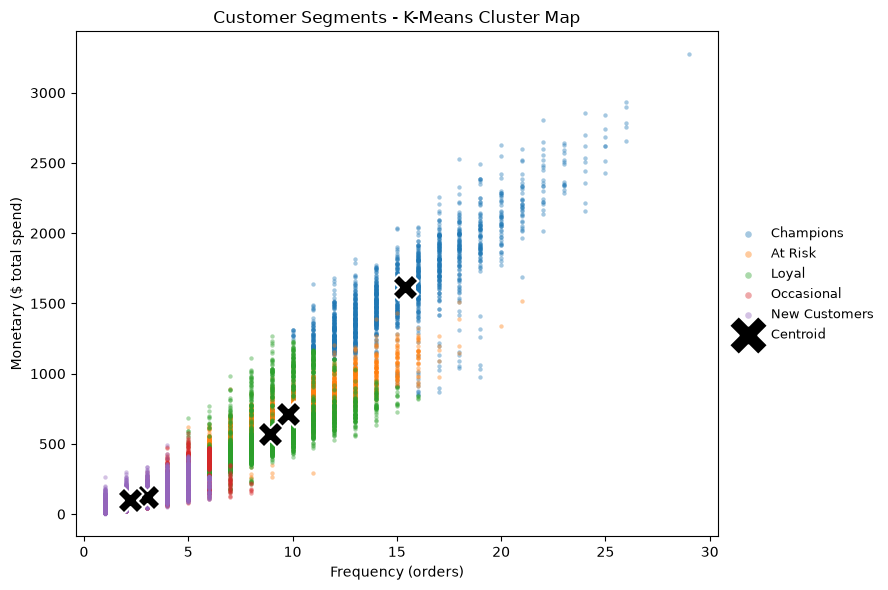

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))

for seg in segments_order:
    subset = sample_df[sample_df["segment_name"] == seg]
    ax.scatter(subset["frequency"], subset["monetary"], s=10, alpha=0.4,
               label=seg, color=colors[seg], linewidths=0)

centroids = segment_summary.set_index("segment_name").loc[segments_order]
ax.scatter(centroids["avg_frequency"], centroids["avg_monetary"],
           marker="X", s=350, c="black", edgecolor="white", linewidth=1.5,
           label="Centroid", zorder=5)

ax.set_xlabel("Frequency (orders)")
ax.set_ylabel("Monetary ($ total spend)")
ax.set_title("Customer Segments - K-Means Cluster Map")

# Place the legend fully outside the axes, to the right, instead of inside a corner
ax.legend(markerscale=1.5, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5),
          borderaxespad=0, frameon=False)

plt.tight_layout()
plt.show()

### A closer look: two RFM dimensions at a time

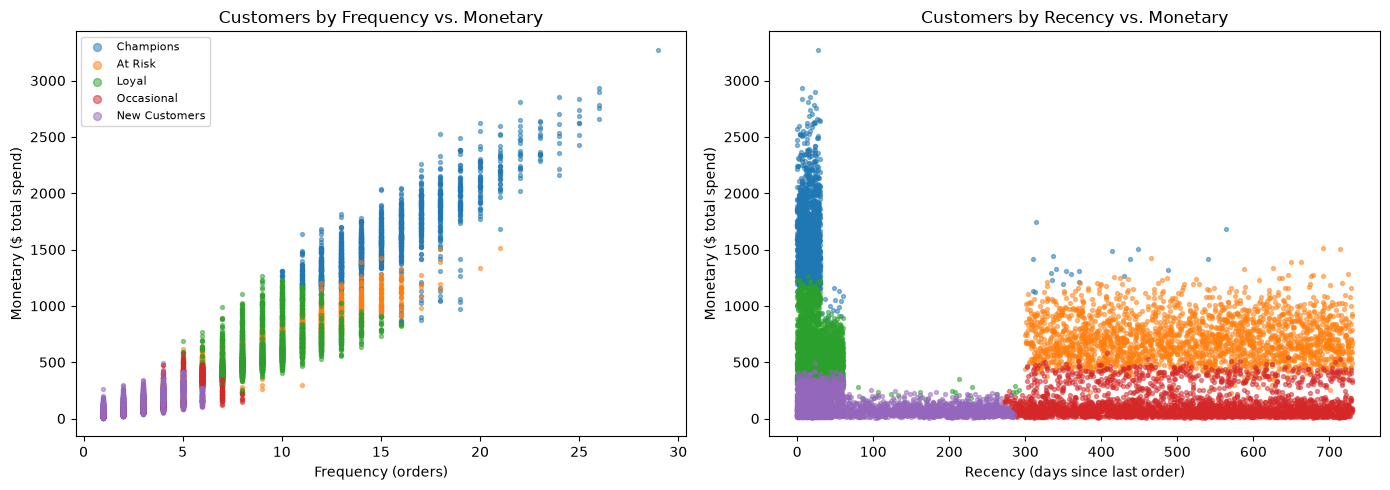

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segments_order = segment_summary.sort_values("avg_monetary", ascending=False)["segment_name"].tolist()
palette = plt.get_cmap("tab10")
colors = {seg: palette(i) for i, seg in enumerate(segments_order)}

for seg in segments_order:
    subset = sample_df[sample_df["segment_name"] == seg]
    axes[0].scatter(subset["frequency"], subset["monetary"], s=8, alpha=0.5, label=seg, color=colors[seg])
axes[0].set_xlabel("Frequency (orders)")
axes[0].set_ylabel("Monetary ($ total spend)")
axes[0].set_title("Customers by Frequency vs. Monetary")
axes[0].legend(markerscale=2, fontsize=8)

for seg in segments_order:
    subset = sample_df[sample_df["segment_name"] == seg]
    axes[1].scatter(subset["recency_days"], subset["monetary"], s=8, alpha=0.5, label=seg, color=colors[seg])
axes[1].set_xlabel("Recency (days since last order)")
axes[1].set_ylabel("Monetary ($ total spend)")
axes[1].set_title("Customers by Recency vs. Monetary")

plt.tight_layout()
plt.show()

### Segment profile at a glance

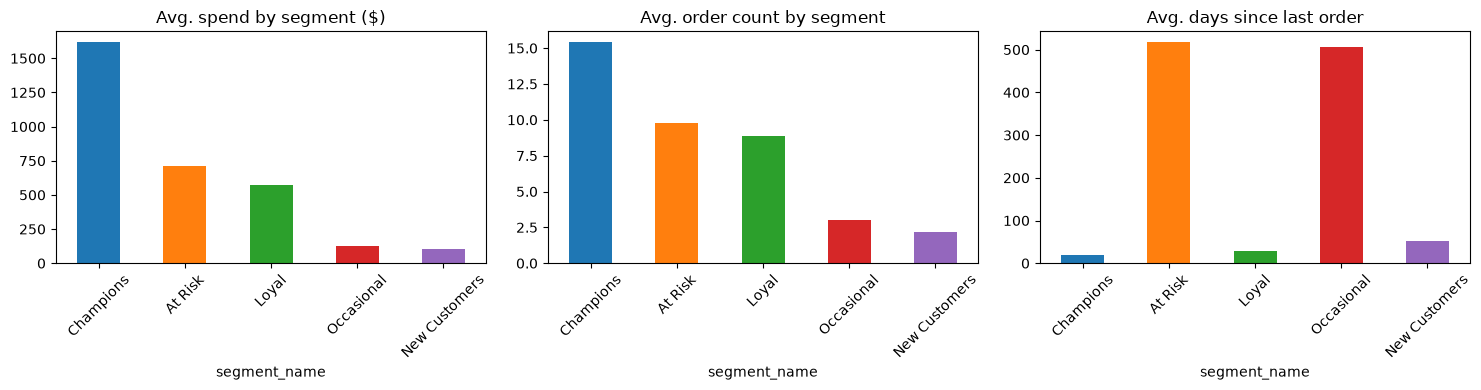

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plot_df = segment_summary.set_index("segment_name").loc[segments_order]

plot_df["avg_monetary"].plot(kind="bar", ax=ax[0], color=[colors[s] for s in segments_order])
ax[0].set_title("Avg. spend by segment ($)")
ax[0].tick_params(axis='x', rotation=45)

plot_df["avg_frequency"].plot(kind="bar", ax=ax[1], color=[colors[s] for s in segments_order])
ax[1].set_title("Avg. order count by segment")
ax[1].tick_params(axis='x', rotation=45)

plot_df["avg_recency_days"].plot(kind="bar", ax=ax[2], color=[colors[s] for s in segments_order])
ax[2].set_title("Avg. days since last order")
ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [28]:
print("Customers per segment:")
for _, row in segment_summary.sort_values("customers", ascending=False).iterrows():
    print(f"  {row['segment_name']:<15} {row['customers']:>8,} customers   "
          f"(avg spend ${row['avg_monetary']:,.0f}, avg {row['avg_frequency']:.1f} orders, "
          f"last order {row['avg_recency_days']:.0f} days ago)")

Customers per segment:
  New Customers    153,040 customers   (avg spend $102, avg 2.2 orders, last order 52 days ago)
  Loyal             75,590 customers   (avg spend $572, avg 8.9 orders, last order 29 days ago)
  Occasional        74,342 customers   (avg spend $125, avg 3.0 orders, last order 507 days ago)
  At Risk           58,574 customers   (avg spend $712, avg 9.8 orders, last order 517 days ago)
  Champions         38,454 customers   (avg spend $1,616, avg 15.4 orders, last order 20 days ago)


### Business takeaway

Each segment above suggests a distinct action: retention perks for **Champions**,
win-back campaigns for **At Risk** customers, onboarding nudges for **New Customers**,
and low-cost re-engagement (e.g. a newsletter) for **Occasional** buyers - all derived
automatically from ~2.4 million raw transactions, with the heavy aggregation and the
clustering itself computed inside WarehousePG via MADlib rather than in a client
notebook or spreadsheet.